In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="resnet18"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.1*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.14764110299093383,train_accu=0.9523714285714285
Epoch=0,valid_loss=0.229139837962389,valid_accu=0.921
0
Epoch=1,train_loss=0.09070713381213802,train_accu=0.9716571428571429
Epoch=1,valid_loss=0.2041961694419384,valid_accu=0.932
0
Epoch=2,train_loss=0.06090674131778734,train_accu=0.9803714285714286
Epoch=2,valid_loss=0.18832482427954675,valid_accu=0.939
0
Epoch=3,train_loss=0.04519599465727806,train_accu=0.9854857142857143
Epoch=3,valid_loss=0.19172175097167493,valid_accu=0.9382
Epoch=4,train_loss=0.030259123923310212,train_accu=0.9905714285714285
Epoch=4,valid_loss=0.1669497622013092,valid_accu=0.9464
0
Epoch=5,train_loss=0.040969104179394034,train_accu=0.9865428571428572
Epoch=5,valid_loss=0.2163301103785634,valid_accu=0.9345
Epoch=6,train_loss=0.025432088332809508,train_accu=0.9924
Epoch=6,valid_loss=0.18680148460380733,valid_accu=0.942
Epoch=7,train_loss=0.024069589049621885,train_accu=0.9928285714285714
Epoch=7,valid_loss=0.18975787150673568,valid_accu=0.9451
E

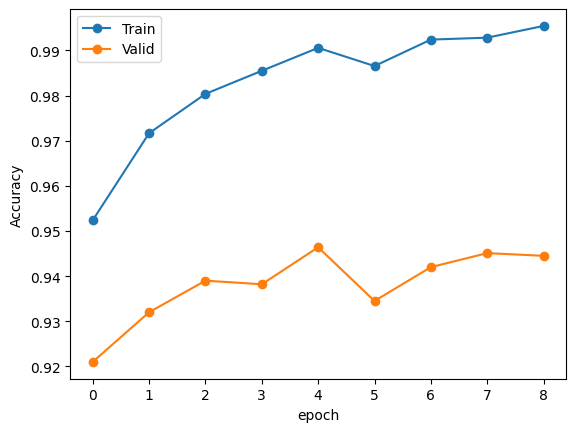

In [10]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_10.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.03031128208222134, 0.9910571428571429)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.1676151985116303, 0.9463)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=p
each_accu

airplane      0.994839
automobile    0.993669
bird          0.986115
cat           0.971609
deer          0.991733
dog           0.991419
frog          0.996595
horse         0.996003
ship          0.991568
truck         0.996861
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(4).index.map(trainset.dataset.classess)]
targetF

[3, 2, 5, 8, 4]

In [17]:
targetF=[0,1,8,9]

In [18]:
 #將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    # elif(loss>split_mode[1] and loss<split_mode[0]):
                    #    indexF.append(idx.cpu().numpy().item())  
                    #    indexT.append(idx.cpu().numpy().item())
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                elif(split_mode=='TandF'):
                    
                    if(t!=pred):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                     
                   
                elif(split_mode[0]=='softmax'):
                 
                    if(softmax.max()<split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                     

                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t==0):
                            indexT.append(idx.cpu().numpy().item()) 
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                    

            torch.cuda.empty_cache() 
        return indexF,indexT

In [19]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(14025, 24463)

In [20]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(4006, 6987)

In [21]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                if(t!=0):
                    flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                    flat_data.append(d.cpu().numpy()) 
                
    return flat_data,flat_true

In [22]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [23]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [24]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None,trainclassnum=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.fc=nn.Linear(model.fc.in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.fc=nn.Linear(model.fc.in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
        
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision"):
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.008851251849677914,train_accu=0.9974612845899975
Epoch=0,valid_loss=0.02203215918994541,valid_accu=0.9922282669035195
0
Epoch=1,train_loss=0.016778429737733885,train_accu=0.994065752729119
Epoch=1,valid_loss=0.03389909159008712,valid_accu=0.9875652270456312
Epoch=2,train_loss=0.004341603192430344,train_accu=0.9988893120081239
Epoch=2,valid_loss=0.017187281841524325,valid_accu=0.993338514488731
0
Epoch=3,train_loss=0.003404186095946327,train_accu=0.9987623762376238
Epoch=3,valid_loss=0.020464848591585715,valid_accu=0.994115687798379
0
Epoch=4,train_loss=0.0032616950198800132,train_accu=0.9988893120081239
Epoch=4,valid_loss=0.019107866465379958,valid_accu=0.9930054402131675
Epoch=5,train_loss=0.003217769891044871,train_accu=0.9991749174917491
Epoch=5,valid_loss=0.021494192246113847,valid_accu=0.9921172421449983
Epoch=6,train_loss=0.0011018204849043247,train_accu=0.9996826605737497
Epoch=6,valid_loss=0.012233940421768766,valid_accu=0.9962251582102809
0
Epoch=7,train_l

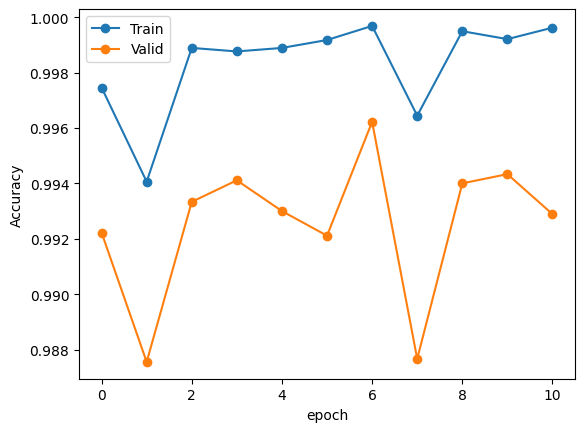

In [25]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

In [26]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.03824916609219117,train_accu=0.9889220455381597
Epoch=0,valid_loss=0.20511830265308392,valid_accu=0.9360240446543581
0
Epoch=1,train_loss=0.02455317909077309,train_accu=0.9931733638556187
Epoch=1,valid_loss=0.19846004683802154,valid_accu=0.941319593530843
0
Epoch=2,train_loss=0.031387091630638284,train_accu=0.9896987286923108
Epoch=2,valid_loss=0.2246991257582868,valid_accu=0.9295835122370116
Epoch=3,train_loss=0.02362979679193578,train_accu=0.9930098516126395
Epoch=3,valid_loss=0.20587317921680853,valid_accu=0.9381708887934735
Epoch=4,train_loss=0.01396315172819556,train_accu=0.9955034133180722
Epoch=4,valid_loss=0.2079072920380274,valid_accu=0.9426077000143123
0
Epoch=5,train_loss=0.013019359871706734,train_accu=0.9962392184114786
Epoch=5,valid_loss=0.19501930148718916,valid_accu=0.9416058394160584
Epoch=6,train_loss=0.014729207578897783,train_accu=0.9955034133180722
Epoch=6,valid_loss=0.22052444626166787,valid_accu=0.932732216974381
Epoch=7,train_loss=0.01538136

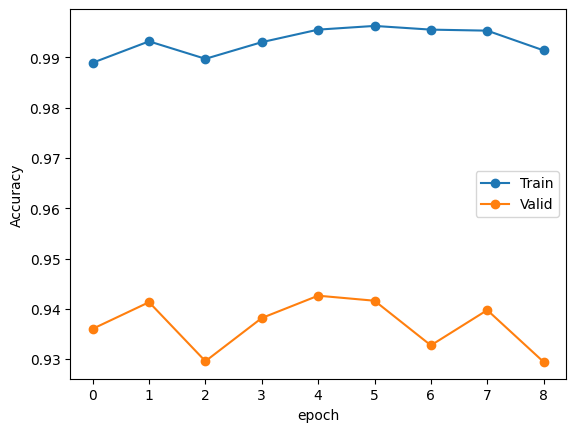

In [75]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [28]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 150, 150]           9,408
       BatchNorm2d-2         [-1, 64, 150, 150]             128
              ReLU-3         [-1, 64, 150, 150]               0
         MaxPool2d-4           [-1, 64, 75, 75]               0
            Conv2d-5           [-1, 64, 75, 75]          36,864
       BatchNorm2d-6           [-1, 64, 75, 75]             128
              ReLU-7           [-1, 64, 75, 75]               0
            Conv2d-8           [-1, 64, 75, 75]          36,864
       BatchNorm2d-9           [-1, 64, 75, 75]             128
             ReLU-10           [-1, 64, 75, 75]               0
       BasicBlock-11           [-1, 64, 75, 75]               0
           Conv2d-12           [-1, 64, 75, 75]          36,864
      BatchNorm2d-13           [-1, 64, 75, 75]             128
             ReLU-14           [-1, 64,

Epoch=0,train_loss=0.022929054849487256,train_accu=0.9940819964349377
Epoch=0,valid_loss=0.0858790650517418,valid_accu=0.9697953070394408
0
Epoch=1,train_loss=0.015713896694395577,train_accu=0.9952941176470588
Epoch=1,valid_loss=0.09654460231579666,valid_accu=0.9712930604093859
0
Epoch=2,train_loss=0.006906448431220072,train_accu=0.9983600713012478
Epoch=2,valid_loss=0.08647244304504118,valid_accu=0.9730404393409885
0
Epoch=3,train_loss=0.00855826383095306,train_accu=0.9976470588235294
Epoch=3,valid_loss=0.09399315830042536,valid_accu=0.9707938092860708
Epoch=4,train_loss=0.006232226246307188,train_accu=0.9983600713012478
Epoch=4,valid_loss=0.08150947735892702,valid_accu=0.973290064902646
0
Epoch=5,train_loss=0.015278439855936802,train_accu=0.9950089126559715
Epoch=5,valid_loss=0.12090000104302326,valid_accu=0.9633050424363455
Epoch=6,train_loss=0.008888340279725156,train_accu=0.9972192513368984
Epoch=6,valid_loss=0.0999176295088426,valid_accu=0.9700449326010984
Epoch=7,train_loss=0.00

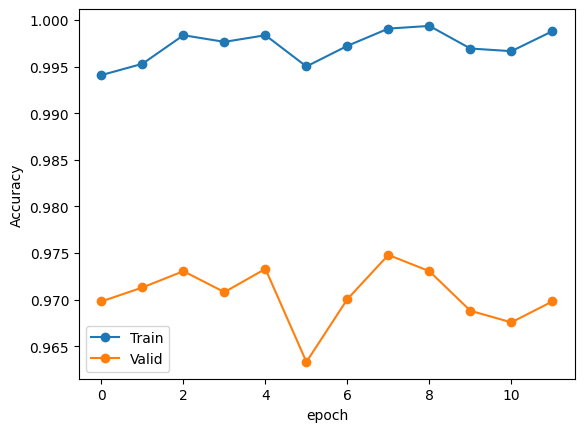

In [29]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [30]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.0011018204849043247, 0.9996826605737497)

In [31]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.012233940421768766, 0.9962251582102809)

In [76]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.014900198766286853, 0.9951763888321138)

In [77]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.003173695534929208, 0.9992156862745099)

In [78]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.2036913872102103, 0.9421783311864892)

In [35]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.09389957861128136, 0.9742885671492761)

In [79]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.011547205652163496, 0.9964, 14025)

In [80]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.17567865748479963, 0.9522, 4006)

In [81]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.020298628212005964, 0.9955142857142857, 12044, 22956)

In [82]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.21342684894334524, 0.9467, 3437, 6563)

In [83]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [84]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.030311,0.991057,0.167615,0.946300
1,Model_Decision,0.001102,0.999683,0.012234,0.996225
2,Model_T,0.014900,0.995176,0.203691,0.942178
3,Model_F,0.003174,0.999216,0.093900,0.974289
4,Total_Model,0.020299,0.995514,0.213427,0.946700
5,Total_Model_without_decision,0.011547,0.996400,0.175679,0.952200


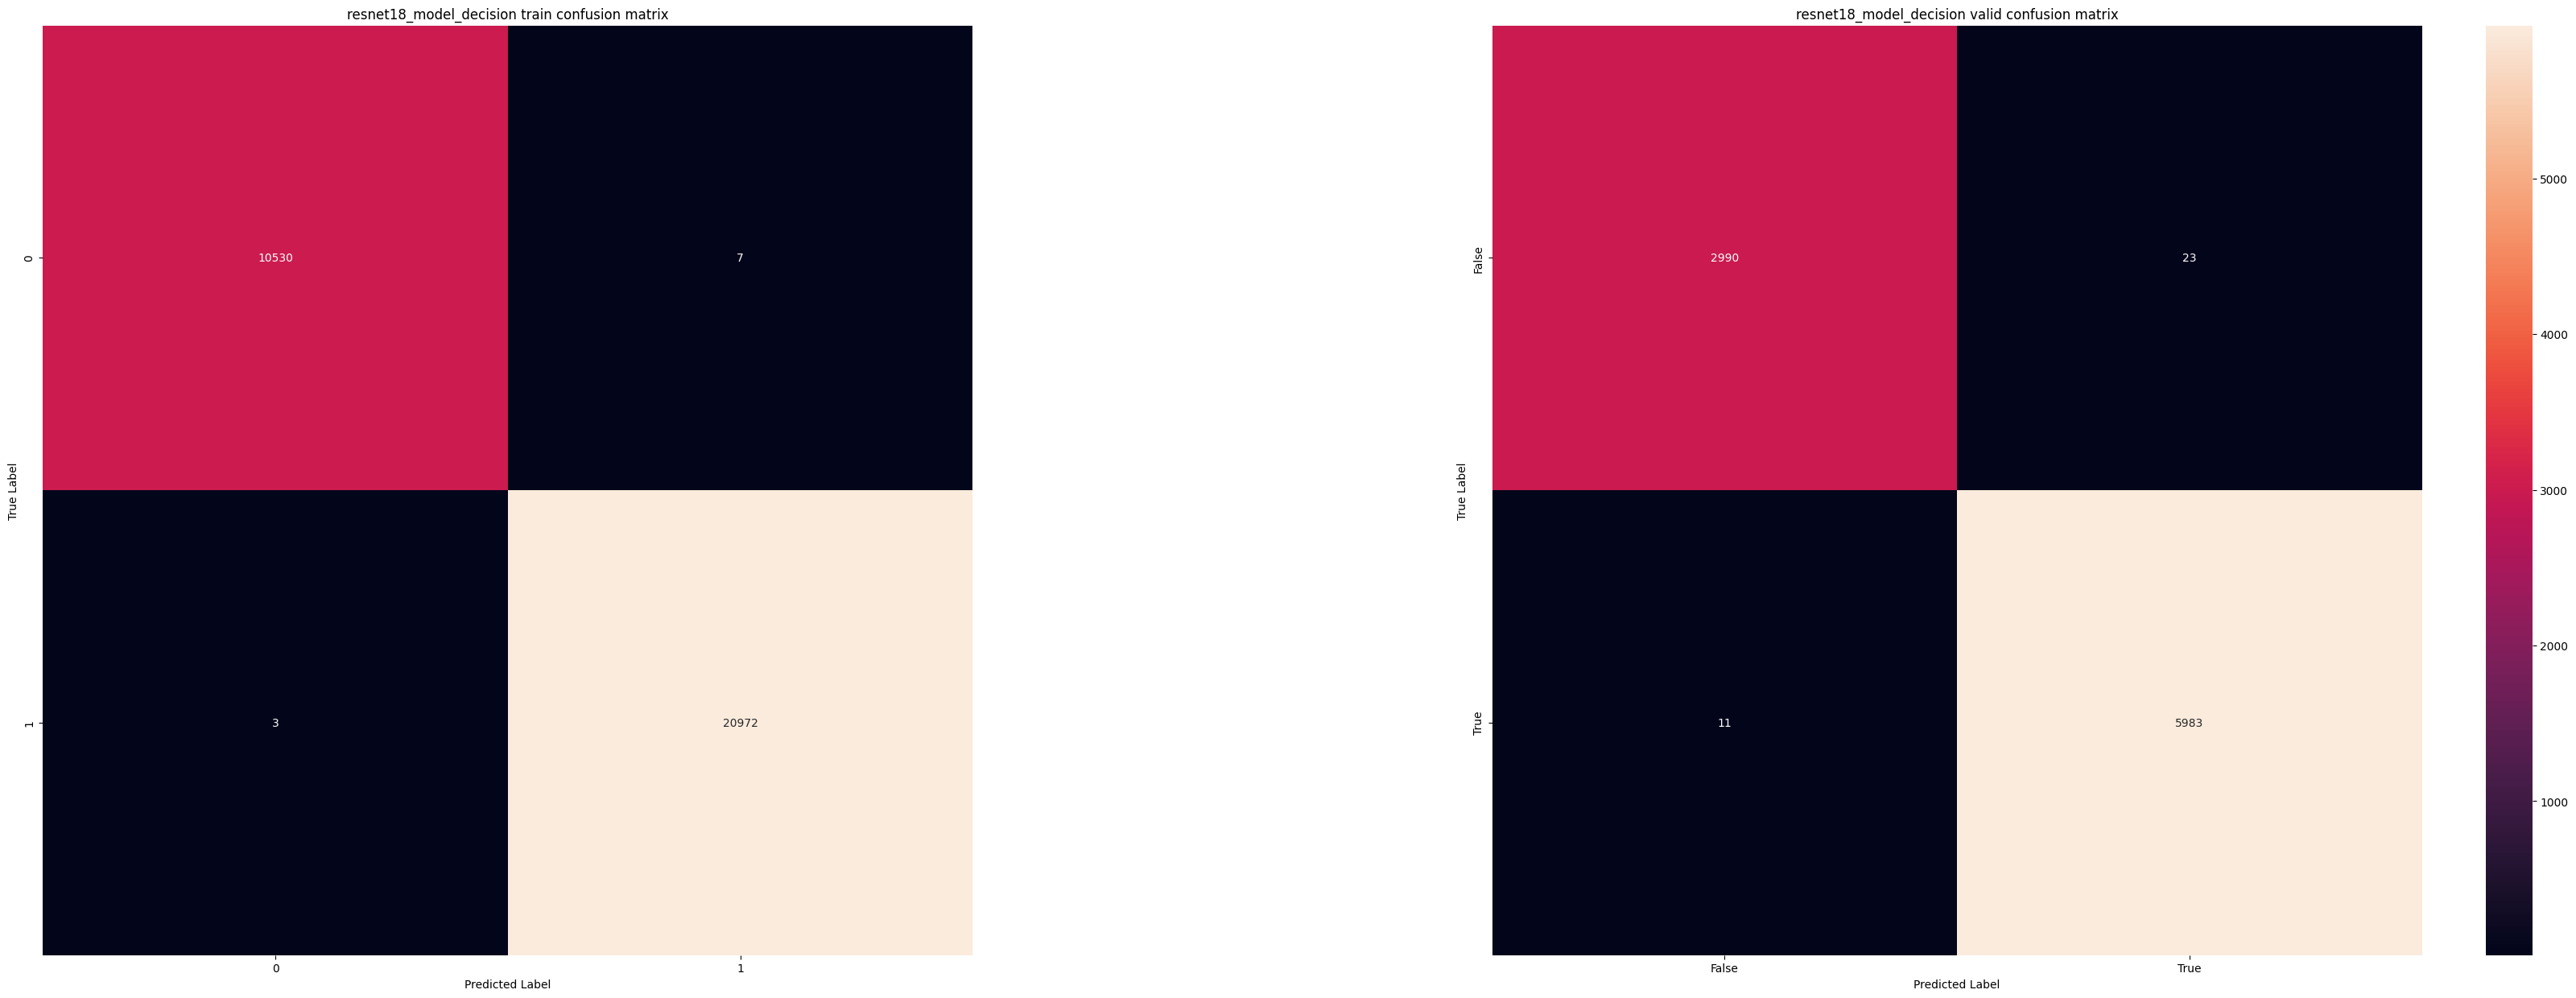

In [42]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

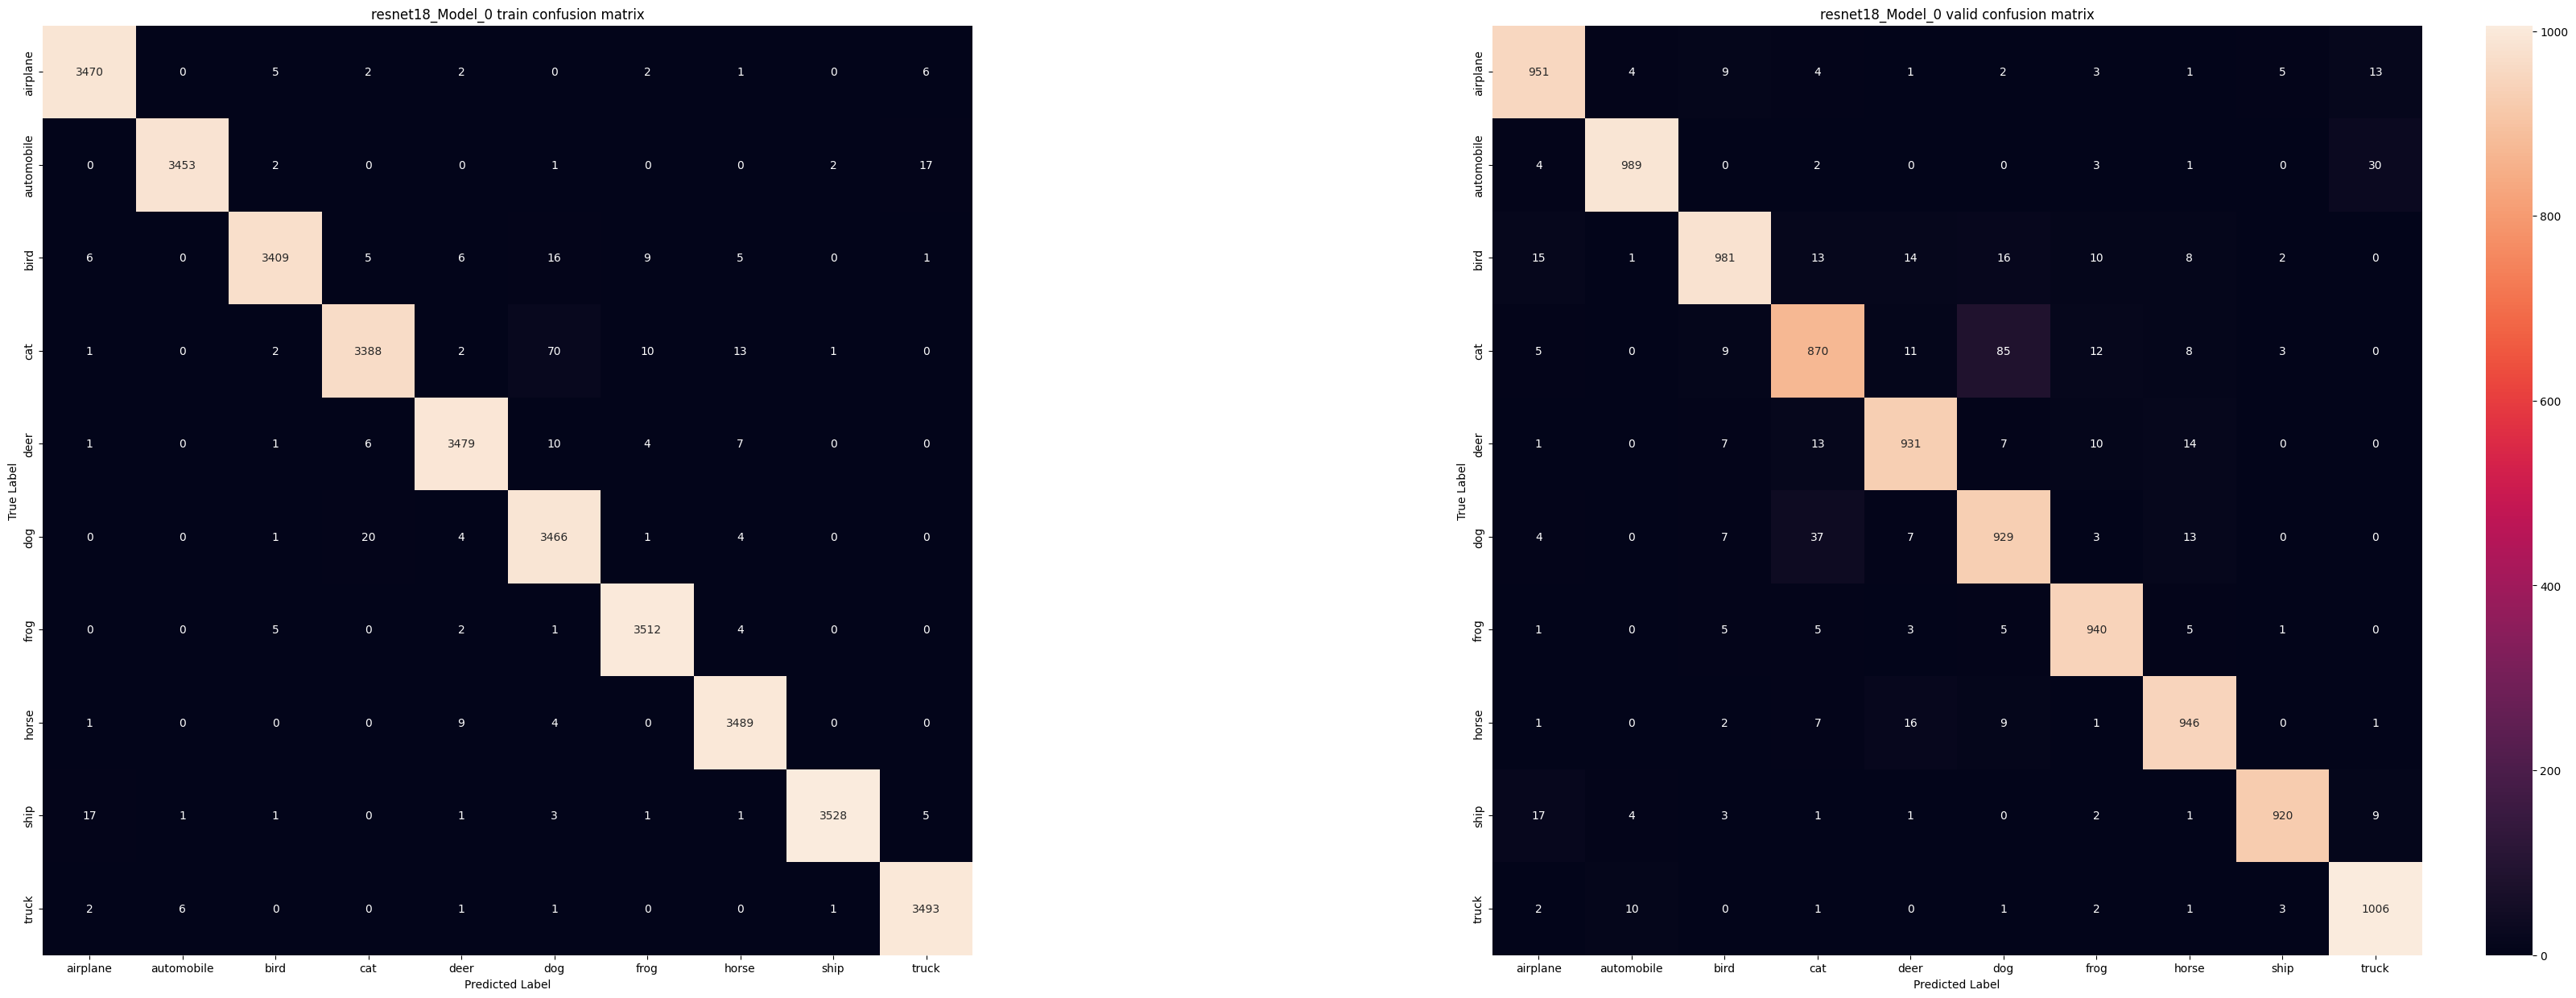

In [43]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

In [44]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements, top_positions

In [45]:
top_elements, top_positions=calculate_confusion(confusion_matrix_train,N=15)

Top 15 Elements:
[0.02579539 0.00660442 0.00491433 0.00477797 0.00456467 0.00402226
 0.00399479 0.00372813 0.0031691  0.00286779 0.00229096 0.00228604
 0.00228394 0.00202067 0.0020199 ]
Top 15 Positions:
[(5, 3), (9, 1), (5, 2), (8, 0), (7, 4), (6, 2), (5, 4), (7, 3), (2, 0), (6, 3), (9, 0), (7, 5), (4, 3), (4, 2), (3, 2)]


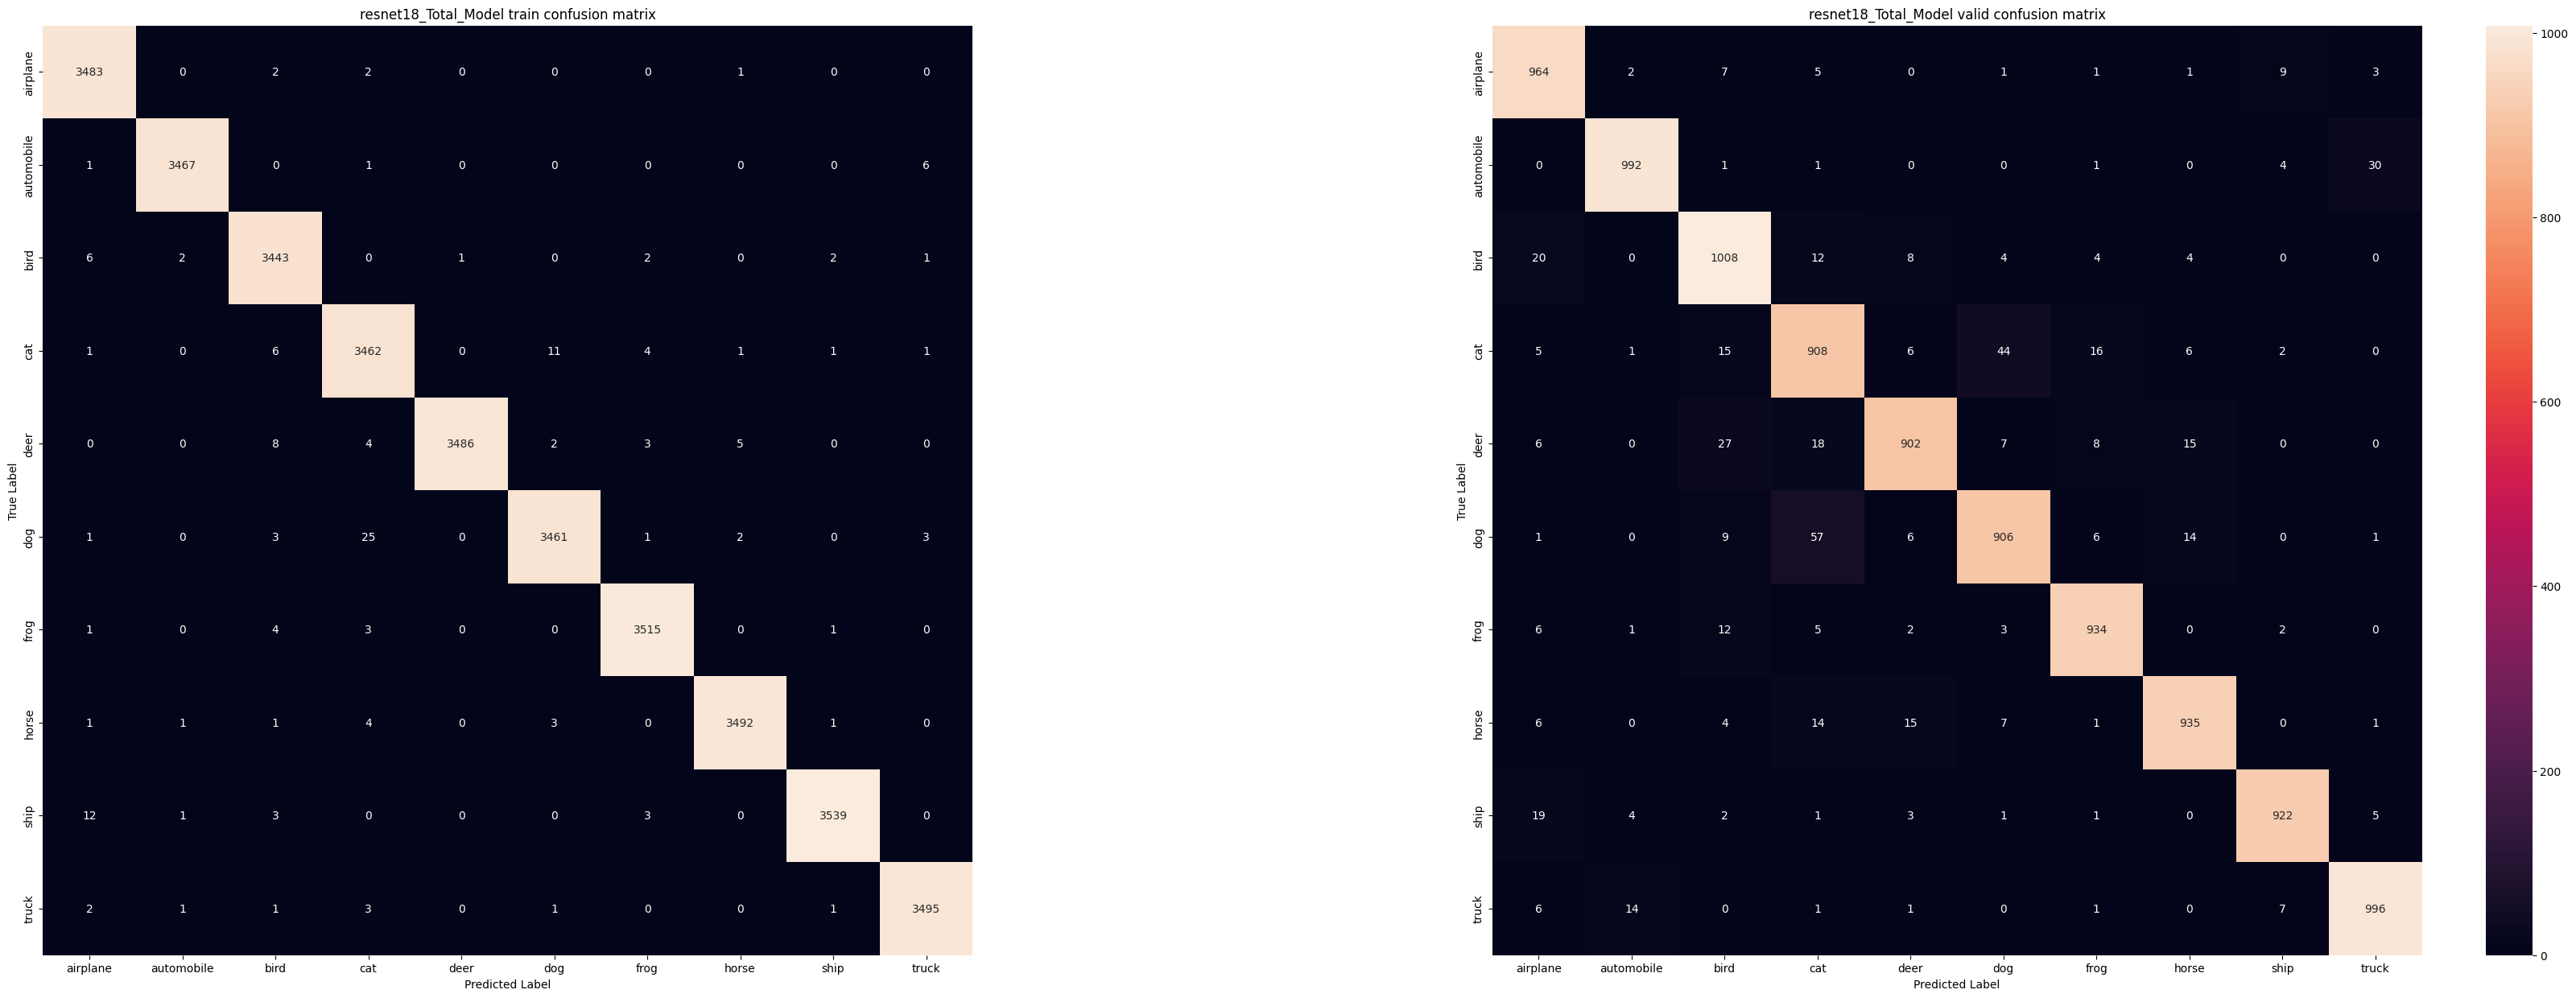

In [85]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

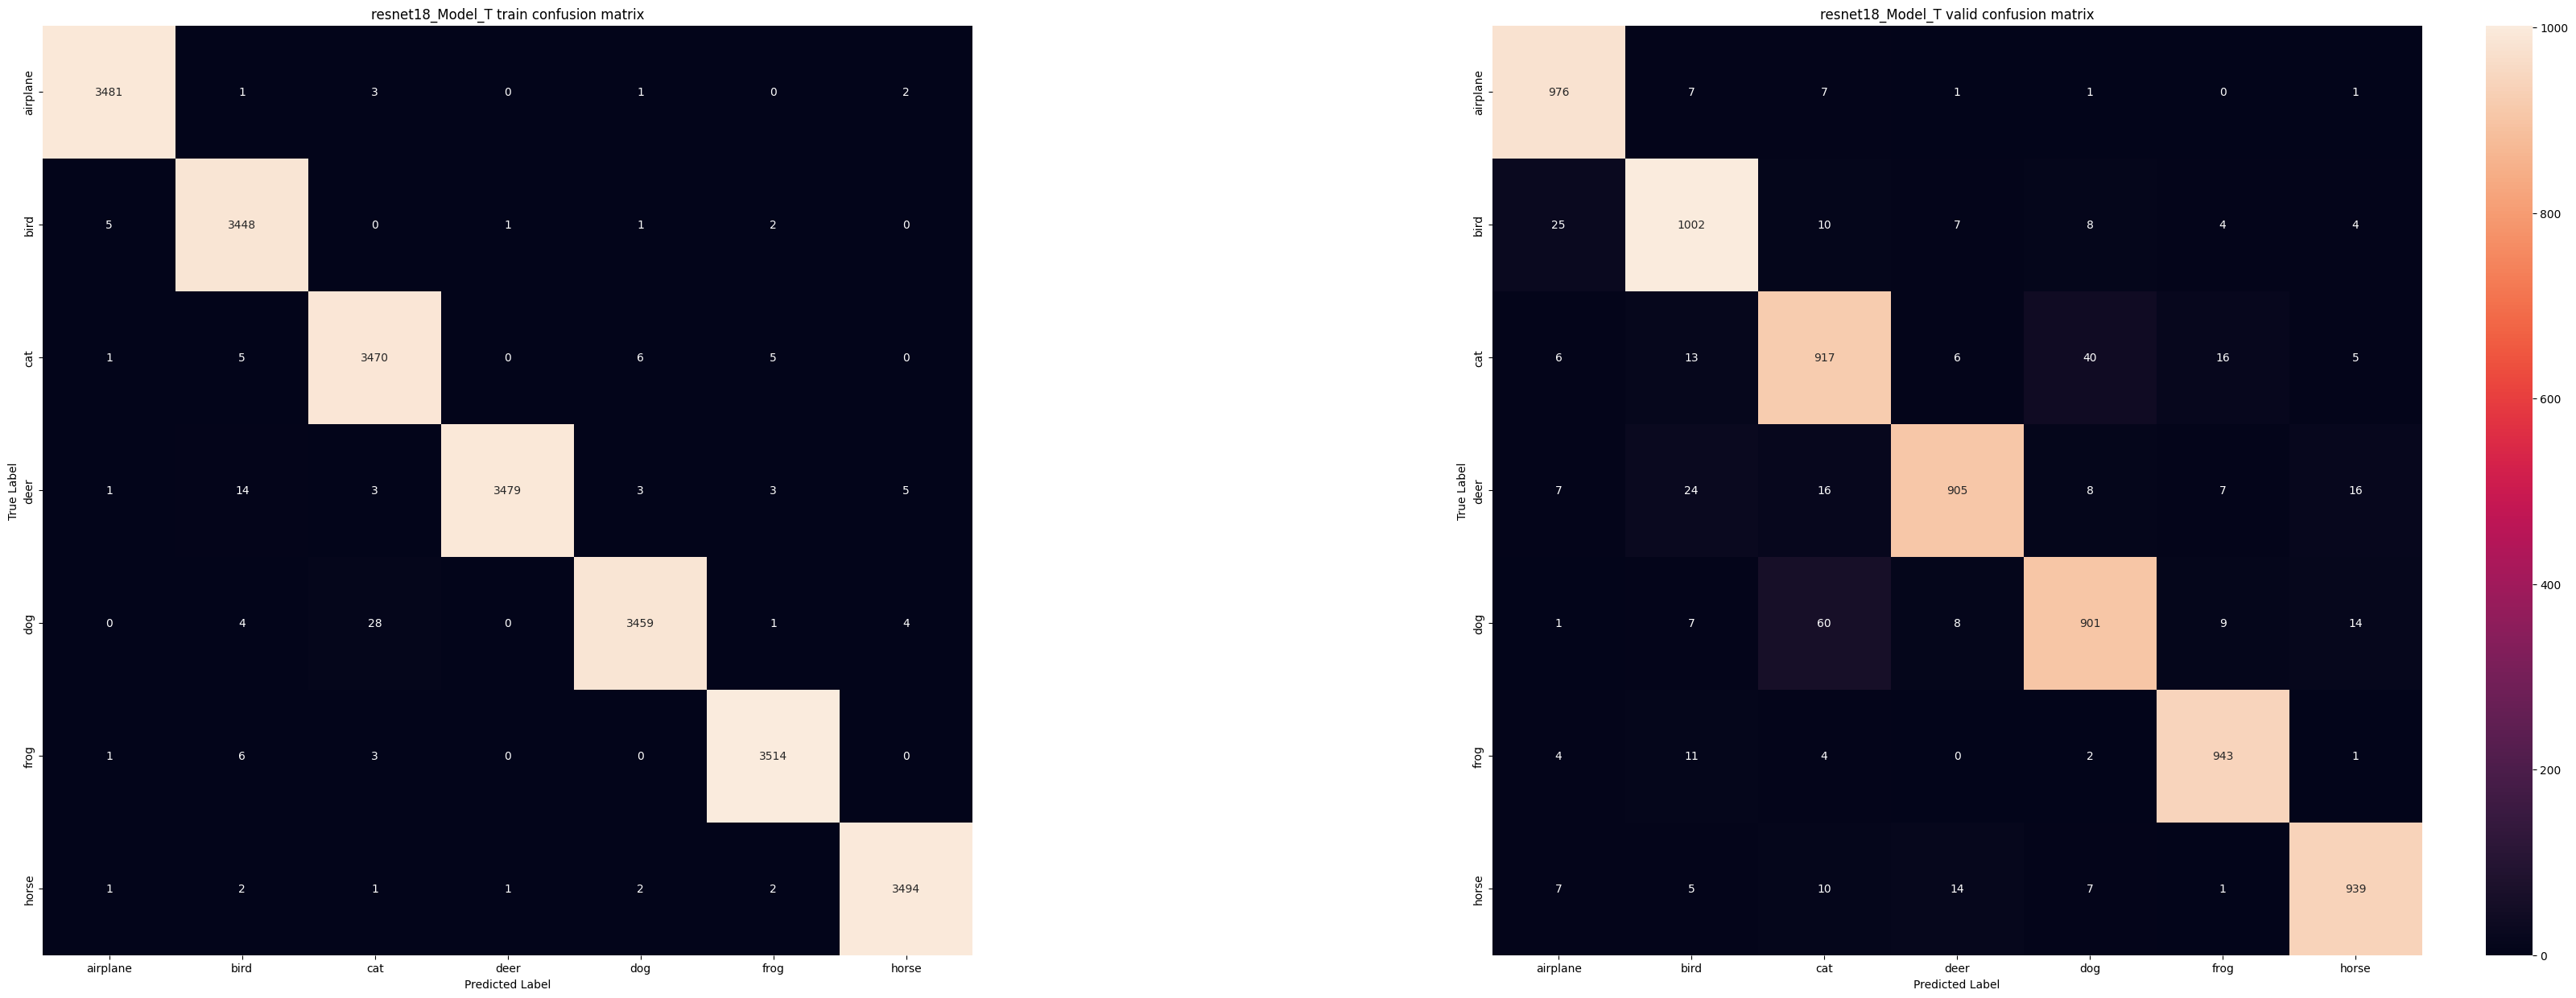

In [86]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

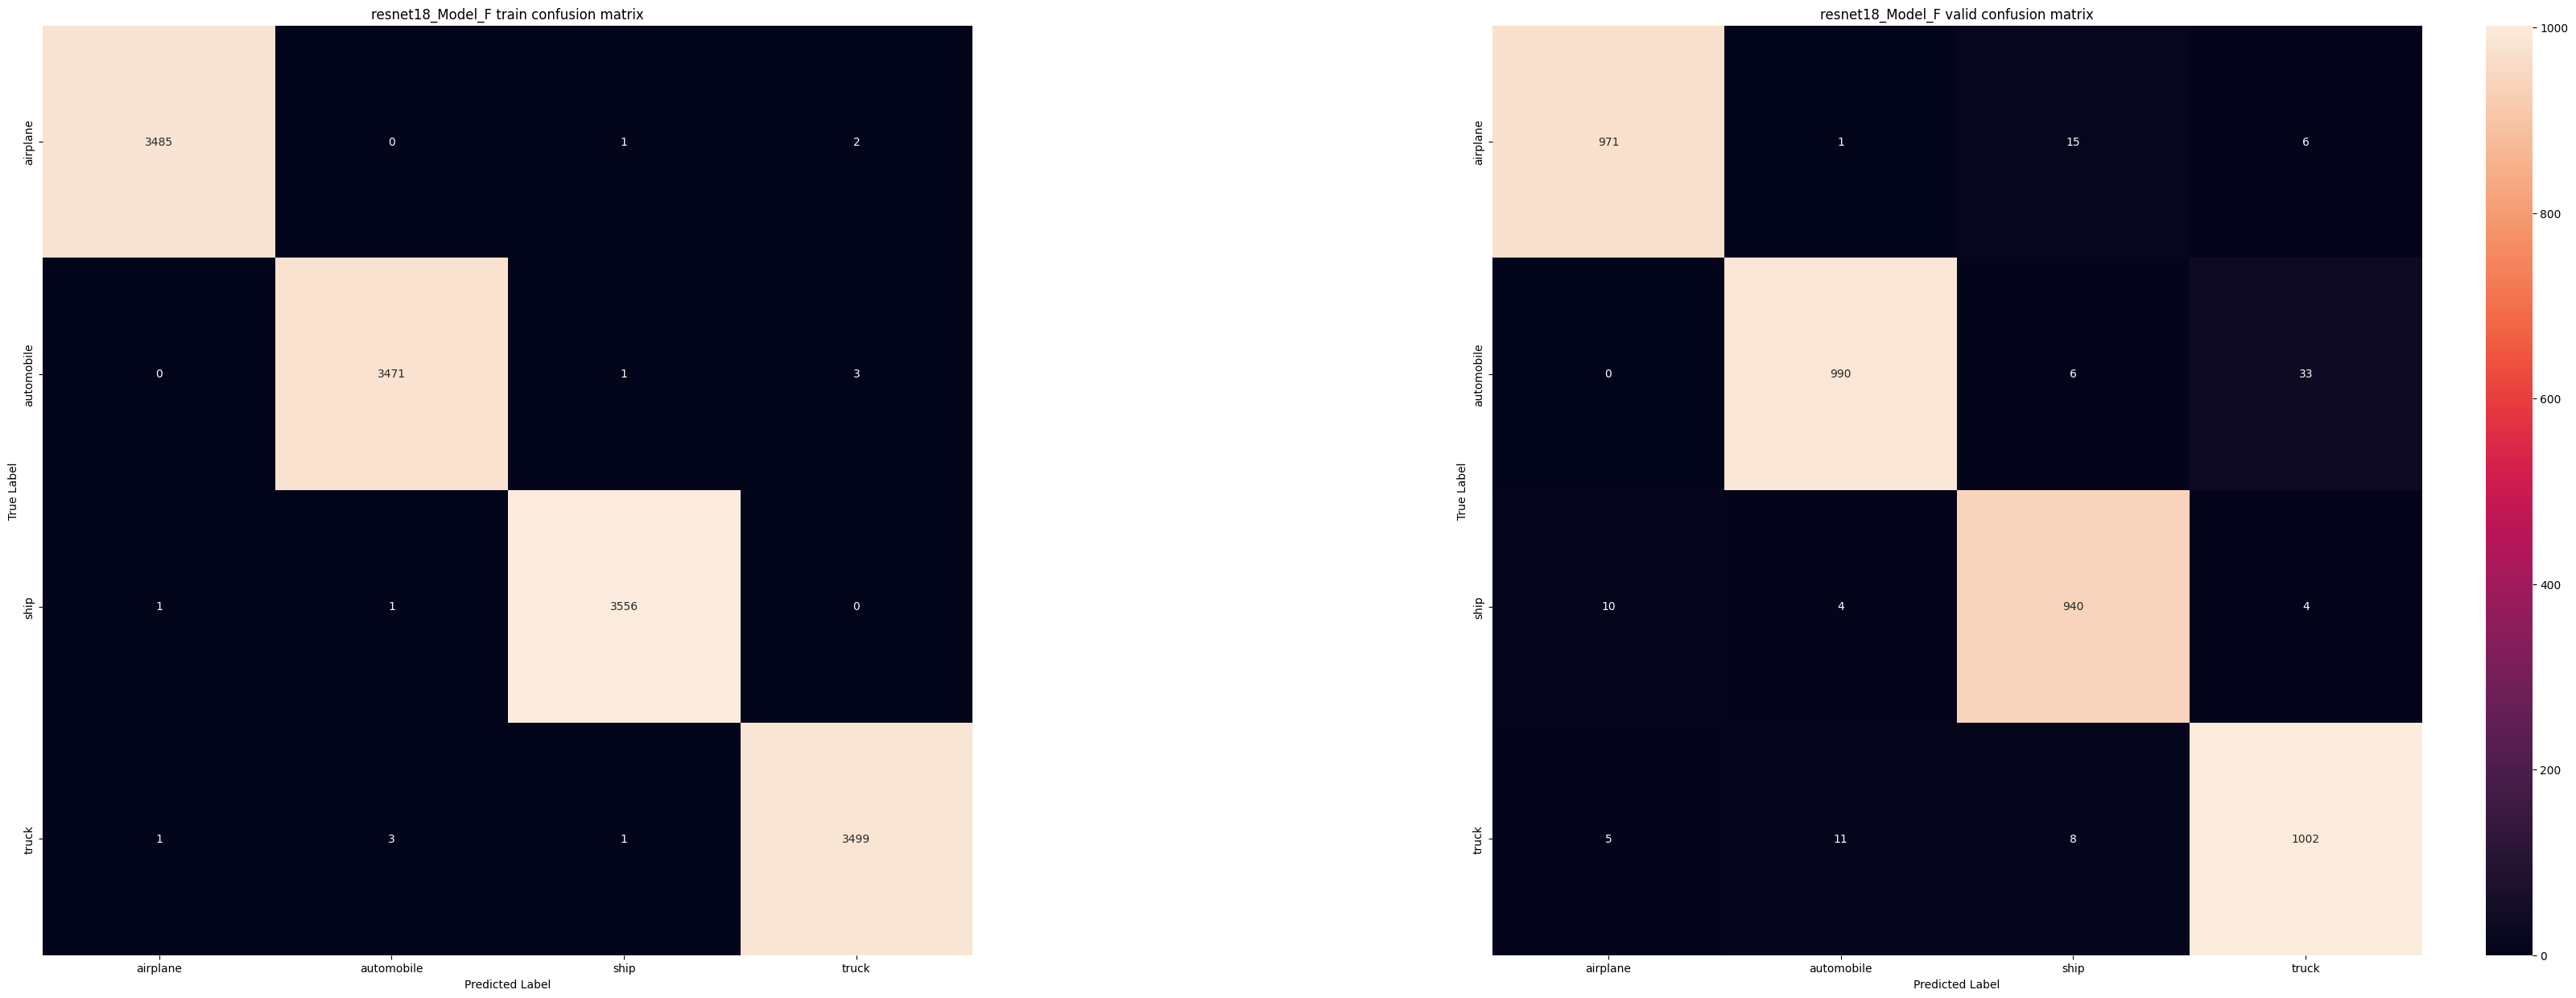

In [48]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [49]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [50]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,37624,7,0,7,7,0.999985,0.999971,0.999995,1.000000,False,True,True,True,True
1,18639,1,1,0,1,0.997528,0.882432,0.994048,1.000000,True,False,True,False,False
2,10209,3,8,3,3,0.647260,0.999731,0.981786,1.000000,False,True,True,True,True
3,75,1,1,6,1,0.999945,0.762912,0.999680,1.000000,True,False,True,False,False
4,37569,4,0,4,4,0.525700,0.999982,0.999829,1.000000,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,23194,0,0,0,0,0.999949,0.999871,0.955065,0.688889,True,True,True,True,False
34996,4789,6,0,6,6,0.770567,0.999906,0.999926,1.000000,False,True,True,True,True
34997,23310,7,0,7,7,0.682253,0.994936,0.999350,1.000000,False,True,True,True,True
34998,8089,9,9,0,9,0.999526,0.613444,0.999964,1.000000,True,False,True,False,False


In [51]:
df_results[(df_results['Target']==0)&(df_results['Match_F']!=True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
7129,40492,0,9,0,0,0.617182,0.998320,0.990001,0.561201,False,True,True,True,False
19333,42883,0,9,0,0,0.627140,1.000000,0.998590,0.997878,False,True,True,False,False
29141,46367,0,8,0,0,0.994252,0.999995,0.999912,0.782629,False,True,True,True,False


In [52]:
df_results[(df_results['Target']==0)&(df_results['Decision']!=True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
48,8425,0,0,0,0,0.999742,0.999985,0.995813,0.999998,True,True,True,False,False
70,37999,0,0,0,0,0.999946,0.999964,0.999449,0.942447,True,True,True,False,False
72,45393,0,0,0,0,1.000000,1.000000,1.000000,0.998540,True,True,True,False,False
95,436,0,0,0,0,0.999940,0.999758,0.999984,0.840880,True,True,True,False,False
100,6860,0,0,0,0,0.999791,0.999987,0.999321,0.961339,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34824,13031,0,0,0,0,0.999208,0.999995,0.998819,1.000000,True,True,True,False,False
34853,2513,0,0,0,0,0.999978,0.999746,0.949561,0.999937,True,True,True,False,False
34888,3694,0,0,0,0,0.999946,1.000000,0.999987,0.998798,True,True,True,False,False
34894,21439,0,0,0,0,0.999999,0.999999,0.999995,0.998807,True,True,True,False,False


In [53]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
12,32256,0,0,0,0,0.999972,0.999881,0.999747,0.996799,True,True,True,True,False
15,21972,8,8,2,8,0.999972,0.917085,0.983919,0.864319,True,False,True,True,False
28,46655,0,0,0,0,0.999883,0.999919,0.997589,0.999877,True,True,True,True,False
55,29515,0,0,0,0,0.998742,0.991093,0.990948,0.999972,True,True,True,True,False
59,21881,0,0,0,0,0.999979,0.999999,0.999995,0.992860,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34890,22799,0,0,0,0,0.999165,0.999970,0.999775,0.505626,True,True,True,True,False
34932,20452,0,0,0,0,0.890005,0.999965,0.999854,0.506293,True,True,True,True,False
34937,40890,0,0,0,0,0.986275,0.594652,0.999638,0.999564,True,True,True,True,False
34985,28619,0,0,0,0,0.999680,0.999794,0.999074,0.967377,True,True,True,True,False


In [54]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

0    1973
8      15
2       5
9       5
1       4
6       3
5       3
7       2
3       2
4       1
Name: Target, dtype: int64

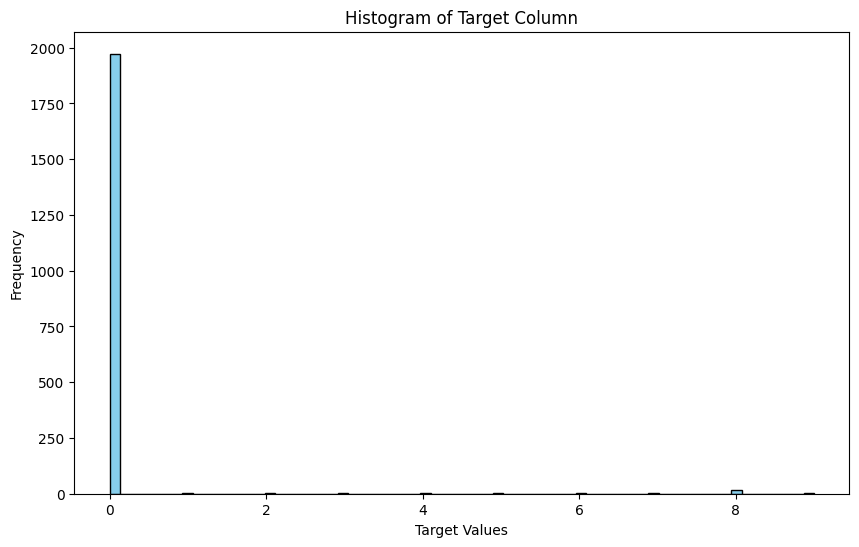

In [55]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [56]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']>df_results['Softmax_T']) & (df_results['flag']==False)])

252

In [57]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']<df_results['Softmax_T']) & (df_results['flag']==True)])

6

In [58]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
15,21972,8,8,2,8,0.999972,0.917085,0.983919,0.864319,True,False,True,True,False
199,29870,2,0,2,2,0.490063,0.972591,0.999918,0.526579,False,True,True,False,True
352,8023,0,0,0,0,1.000000,0.999800,0.999996,0.727510,True,True,True,True,False
359,22858,0,0,0,0,0.999977,0.999815,0.999948,0.859679,True,True,True,True,False
476,6735,0,0,0,0,0.999931,0.999993,0.998578,0.654020,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34665,12129,0,0,0,0,0.999390,0.994056,0.997162,0.852098,True,True,True,True,False
34818,467,0,0,0,0,0.999853,0.999997,0.991264,0.562296,True,True,True,True,False
34890,22799,0,0,0,0,0.999165,0.999970,0.999775,0.505626,True,True,True,True,False
34932,20452,0,0,0,0,0.890005,0.999965,0.999854,0.506293,True,True,True,True,False


In [59]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,21519,9,9,0,9,1.000000,0.974150,1.000000,1.000000,True,False,True,False,False
1,7631,0,0,0,9,0.969121,0.999968,0.986982,1.000000,True,True,False,False,False
2,20725,1,1,0,1,0.999974,0.984137,0.999997,1.000000,True,False,True,False,False
3,15796,7,0,7,7,0.999599,0.999513,0.945565,1.000000,False,True,True,True,True
4,2508,9,9,6,9,0.999935,0.928609,0.998120,1.000000,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,22447,9,9,0,9,0.548969,0.999687,0.944662,1.000000,True,False,True,False,False
9996,19302,9,9,0,9,0.999997,0.578341,0.999772,0.999997,True,False,True,False,False
9997,49966,6,0,6,6,0.994665,0.999986,1.000000,1.000000,False,True,True,True,True
9998,1541,1,1,0,1,0.999898,0.991303,0.999937,1.000000,True,False,True,False,False


In [60]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']>df_results_v['Softmax_T']) & (df_results_v['flag']==False)])

67

In [61]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']<df_results_v['Softmax_T']) & (df_results_v['flag']==True)])

7

In [62]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
10,44961,0,0,0,0,0.999996,0.999987,0.999996,0.782700,True,True,True,True,False
18,47711,0,0,0,0,0.999650,0.997944,0.999097,0.969045,True,True,True,True,False
46,42039,0,0,0,0,0.999986,0.999418,0.997006,0.999717,True,True,True,True,False
90,32204,0,0,2,0,0.993857,0.800618,0.933605,0.999965,True,False,True,True,False
106,18302,0,0,0,0,0.999998,1.000000,0.999999,0.926956,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9917,38770,0,0,0,0,0.955659,0.999150,0.999200,0.852324,True,True,True,True,False
9930,15594,0,0,0,0,0.999956,0.999832,0.997917,0.801364,True,True,True,True,False
9968,39504,0,0,0,0,0.999991,0.999860,0.999986,0.515491,True,True,True,True,False
9991,13420,0,0,0,0,0.961620,0.847368,0.998641,0.999921,True,True,True,True,False


In [63]:
df_results_v[(df_results_v['Target']==0)&(df_results_v['Match_F']!=True)&(df_results_v['Decision']==False)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
2704,12820,0,9,0,9,0.930078,0.998245,0.900681,0.997075,False,True,False,False,False
4366,2675,0,8,0,8,0.999916,0.999943,0.979548,0.985885,False,True,False,False,False
4717,4214,0,9,0,3,0.997896,0.999745,0.470144,0.999996,False,True,False,False,False
4782,37265,0,8,0,8,0.910629,0.695415,0.763837,0.932227,False,True,False,False,False
5231,17232,0,8,0,0,0.985547,0.961598,0.992816,0.618935,False,True,True,False,False
6933,49869,0,8,0,0,0.790980,0.995974,0.845554,0.862944,False,True,True,False,False
7593,45233,0,1,5,1,0.909622,0.985518,0.903438,0.949059,False,False,False,False,False
7959,6132,0,8,0,0,0.974684,0.997176,0.878785,0.999034,False,True,True,False,False
8245,16733,0,8,2,8,0.999276,0.557518,0.517698,0.944470,False,False,False,False,False
8656,38479,0,1,0,1,0.999125,0.992278,0.955156,0.992430,False,True,False,False,False


In [64]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

0    562
8     15
6      4
9      4
7      3
3      3
2      3
1      2
5      1
Name: Target, dtype: int64

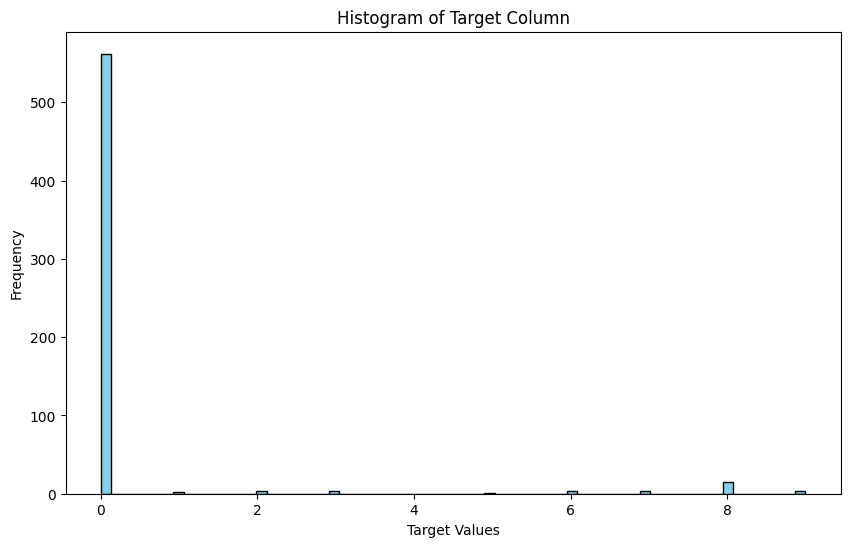

In [65]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [66]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])& (abs(df_results_v['Softmax_F']-df_results_v['Softmax_T'])>0.2)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
112,16004,0,0,0,0,0.998431,0.702325,0.942968,1.000000,True,True,True,True,False
743,32574,8,9,2,2,0.620247,0.995462,0.727124,0.936657,False,False,False,True,False
1043,25198,0,0,0,0,0.997557,0.605781,0.969215,0.999987,True,True,True,True,False
1417,45726,8,8,0,8,0.973279,0.308855,0.632004,0.937295,True,False,True,True,False
1488,14011,8,8,0,8,0.998598,0.480938,0.717164,0.732855,True,False,True,True,False
2647,11487,0,0,2,0,0.999310,0.558184,0.637860,0.999999,True,False,True,True,False
3034,47207,0,0,2,0,0.999927,0.501386,0.848802,0.999290,True,False,True,True,False
3058,349,0,0,0,0,0.997939,0.772737,0.987427,1.000000,True,True,True,True,False
3210,13434,0,0,0,0,0.583290,0.977940,0.527561,0.729611,True,True,True,True,False
3289,15650,6,1,6,3,0.951621,0.342376,0.518504,0.996104,False,True,False,False,True


In [67]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
10,44961,0,0,0,0,0.999996,0.999987,0.999996,0.782700,True,True,True,True,False
18,47711,0,0,0,0,0.999650,0.997944,0.999097,0.969045,True,True,True,True,False
46,42039,0,0,0,0,0.999986,0.999418,0.997006,0.999717,True,True,True,True,False
90,32204,0,0,2,0,0.993857,0.800618,0.933605,0.999965,True,False,True,True,False
106,18302,0,0,0,0,0.999998,1.000000,0.999999,0.926956,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9917,38770,0,0,0,0,0.955659,0.999150,0.999200,0.852324,True,True,True,True,False
9930,15594,0,0,0,0,0.999956,0.999832,0.997917,0.801364,True,True,True,True,False
9968,39504,0,0,0,0,0.999991,0.999860,0.999986,0.515491,True,True,True,True,False
9991,13420,0,0,0,0,0.961620,0.847368,0.998641,0.999921,True,True,True,True,False


In [68]:
# #全部模型裝在一起的表現
# def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
#     total_loss = 0
#     accu = 0
#     flat_true=[]
#     flat_pred=[]
#     sum_F=0
#     sum_T=0
#     with torch.no_grad():
#         for data,target,idx in data_dl:
#             outputs=[]
#             data,target=data.to(device),target.to(device)
#             out_growth = model_0(data)
#             softmax_0=torch.softmax(out_growth, dim=1)

#             out_T = model_T(data)
#             softmax_T=torch.softmax(out_T, dim=1)

#             out_F = model_F(data)
#             softmax_F=torch.softmax(out_F, dim=1)

         
            
#             for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
#                 st_max=torch.max(st).item()
#                 sf_max=torch.max(sf).item()

#                 out_decision=model_decision(d.unsqueeze(0))
#                 _, pred = torch.max(out_decision, dim = 1) 
#                 softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
#                 if(softmax_decision<0.9):
#                     # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
#                     # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
#                     if(sf_max>st_max):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1
#                 else:
                   
#                     if(pred==0):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1

#             outputs = torch.cat(outputs, dim=0)
#             _, y_pred_tag = torch.max(outputs, dim = 1)
#             loss = criterion(outputs, target)


#             flat_true.extend(target.cpu().numpy())
#             flat_pred.extend(y_pred_tag.cpu().numpy())

#             total_loss+= loss.item()*data.size(0)
#             correct=torch.sum(y_pred_tag == target).item()
#             accu += correct      

#     total_loss=total_loss/size
#     accu=accu/size
#     idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
#     confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
#     return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [69]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(sf_max-st_max)>0.3):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [70]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.05317645912827658, 0.9925142857142857, 12147, 22853)

In [71]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.3647618193171918, 0.9371, 3587, 6413)

In [72]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score
#模型表現
def evaluate_metric_model(model,data_dl,size,data_name,mode=None):
        
        model.to(device)
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
            model.eval()   
            for data, target,idx in data_dl:
                    
                    data,target=data.to(device),target.to(device)
                    out= model(data)
                    _, y_pred_tag = torch.max(out, dim = 1)

                    loss = criterion(out, target)
                    # print(target)
                    flat_true.extend(target.cpu().numpy())
                    flat_pred.extend(y_pred_tag.cpu().numpy())

                    total_loss+= loss.item()*data.size(0)
                    correct=torch.sum(y_pred_tag == target).item()
                    accu += correct      

            total_loss=total_loss/size
            accu=accu/size

        # 计算各种指标
        precision = precision_score(flat_true, flat_pred, average='macro')
        recall = recall_score(flat_true, flat_pred, average='macro')
        f1 = f1_score(flat_true, flat_pred, average='macro')
        

        a=sorted(set(flat_true))
        if(mode=='eval'):
            if(data_name=='decision'):
                confusion_matrix_valid=pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a))
            else:
                idxtoclass={v:k for k,v in data_dl.dataset.dataset.classes}
                confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a)).rename(columns=idxtoclass,index=idxtoclass)
            return total_loss,accu,confusion_matrix_valid
        else:
            return total_loss,accu,precision,recall,f1

In [73]:
evaluate_metric_model(model_0,train_dl,train_size,"0",mode=None)

(0.029383925844728948,
 0.9911714285714286,
 0.9912081910512484,
 0.9911546453721589,
 0.9911595536031218)

In [74]:
evaluate_metric_model(model_0,valid_dl,valid_size,"0",mode=None)

(0.16908552765063942,
 0.9472,
 0.9475259929906656,
 0.9474202894325469,
 0.9472909454303323)